In [249]:
from typing import Annotated, TypedDict, List, Literal
import os
import json
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.graph.message import add_messages
from langchain_anthropic import ChatAnthropic
from dotenv import load_dotenv
from IPython.display import Image, display
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import BaseMessage, AIMessage, HumanMessage, SystemMessage
from langchain_core.tools import tool
from langchain.agents import create_agent
from langchain_core.prompts import ChatPromptTemplate
from langchain_mcp_adapters.client import MultiServerMCPClient

In [250]:
llm = ChatAnthropic(model='claude-sonnet-4-6')
llm

ChatAnthropic(output_version=None, profile={'name': 'Claude Sonnet 4.6', 'release_date': '2026-02-17', 'last_updated': '2026-03-13', 'open_weights': False, 'max_input_tokens': 1000000, 'max_output_tokens': 64000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'structured_output': True}, model='claude-sonnet-4-6', max_tokens=64000, anthropic_api_url='https://api.anthropic.com', anthropic_api_key=SecretStr('**********'), anthropic_proxy=None, model_kwargs={})

In [251]:
client = MultiServerMCPClient({
    "tools": {
        "command": "python",
        "args": ["mcp_server.py"],
        "transport": "stdio"
    }
})
tools = await client.get_tools()

In [252]:
class State(MessagesState):
    """State for the multi-agent system"""
    task:str = ""
    steps:str = ""
    file_path: str = ""
    error: str = ""
    retry_count:int = 0
    output: str = ""

In [253]:
def plan_agent(state:State):
    """Agent will take the user input as to what they code would like to generate,
    and create a step-by-step plan that will easily be understand by the next coder agent. 
    The coder agent should not have to make any assumptions or decisions, that is the job of this agent"""
    task = state.get("task", "")

    research_prompt = f"""You are a coding planner. Your job is to take the user's task and produce a clear, numbered step-by-step plan.

    Task: {task}

    Rules:
    - Each step should be specific and actionable
    - Make all decisions and assumptions yourself — the coder should only need to follow the steps, nothing more
    - Include what libraries to use, what functions to create, what the expected output is
    - Format: numbered list, one step per line
    - If something is unfamiliar or unknown, perform an internet search instead of guessing.

    Return only the plan, no preamble or explanation."""

    msg = HumanMessage(content=research_prompt)
    search_web_tool = next(t for t in tools if t.name == "search_web")
    llm_with_tools = llm.bind_tools([search_web_tool])
    content = llm_with_tools.invoke([msg])
    steps = content.content
    return {
        "messages": AIMessage(content=f"Planner complete. Plan:\n{steps}"),
        "steps":steps
    }

In [254]:
async def code_agent(state:State):
    """Agent will utilize the plan created by the Planner Agent and generate code.
    This Agent's job is NOT to make any decisions. Its job is to create the code of the steps exactly."""
    last_message = state["messages"][-1]
    task = state.get("task", "")
    steps = state.get("steps", "")
    error = state.get("error", "")
    file_path = state.get("file_path", "")
    write_file_tool = next(t for t in tools if t.name == "write_file")
    llm_with_tools = llm.bind_tools([write_file_tool])

    prompt = """"""
    
    if len(error) == 0 and len(file_path) == 0:
        prompt = f"""You are a coder. Your goal is to take the steps the planner gave and generate efficient code that accomplishes the task.

        Task: {task}
        Steps: {steps}

        Rules:
        - Code has to compile
        - Do not make any assumptions or decisions. Follow the steps given exactly
        - Write the final code to ./workspace/solution.py using write_file
        - Return only the file path when done, no explanation
        - Once write_file is called successfully, stop immediately. Do NOT read the file back or verify it.
        - Do not call any other tools after write_file
        """ 
    else:
        prompt = f"""You are a debugger. There is an issue with the code somewhere. Your goal is to fix the issue and make sure the code can run properly.
        Error: {error}
        File: {file_path}

        Rules: 
        - First read the file using the read_file on the file_path
        - Code has to compile
        - Do not change the overall goal of the code. Make the minimal changes required to fix the code
        - Write the final code to ./workspace/solution.py using write_file
        - Return only the file path when done, no explanation
        """ 

    msg = HumanMessage(content=prompt)
    content = await llm_with_tools.ainvoke([msg])
    file_path = "./workspace/solution.py"

    return {
        "messages": content,
        "file_path":file_path
    }
    
    

In [255]:
async def exec_agent(state:State):
    "Agent that executes the code given by the Coder."
    file_path = state.get("file_path", "")
    retry_count = state.get("retry_count", 0)
    run_code_tool = next(t for t in tools if t.name == "run_code")
    raw = await run_code_tool.ainvoke({"file_path": file_path})
    result = json.loads(raw[0]["text"])
    if result["success"]:
        return {"output":result["output"], "error":""}
    else:
        return {"error":result["error"], "retry_count":retry_count+1}

In [256]:
def route_coder(state: State):
    last_message = state["messages"][-1]
    # If last message is a ToolMessage, check what tool just ran
    if last_message.type == "tool":
        # Find the AI message before it to see what tool was called
        for msg in reversed(state["messages"][:-1]):
            if hasattr(msg, "tool_calls") and msg.tool_calls:
                tool_name = msg.tool_calls[0]["name"]
                if tool_name == "write_file":
                    return "executor"
                break
        return "coder"  # any other tool result, go back to coder
    
    # If AIMessage with tool calls, execute them
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    
    return "executor"

In [257]:
def route_executor(state: State):
    retry_count = state.get("retry_count", 0)
    output = state.get("output", "")

    if retry_count >= 3 or output:
        return END
    else:
        return "coder"


In [258]:
def route_planner(state: State):
    last_message = state["messages"][-1]
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools1"
    return "coder"


In [259]:
workflow = StateGraph(State)
tool_node = ToolNode(tools)
tool_node1 = ToolNode(tools)

workflow.add_node("planner", plan_agent)
workflow.add_node("coder", code_agent)
workflow.add_node("executor", exec_agent)
workflow.add_node("tools", tool_node)
workflow.add_node("tools1", tool_node)

workflow.add_edge(START, "planner")
workflow.add_conditional_edges("planner", route_planner, {"tools1": "tools1", "coder": "coder"})
workflow.add_edge("tools1", "planner")
workflow.add_conditional_edges("coder", route_coder, {"tools": "tools", "executor": "executor"})
workflow.add_edge("tools", "coder")
workflow.add_conditional_edges("executor", route_executor, {END: END, "coder": "coder"})

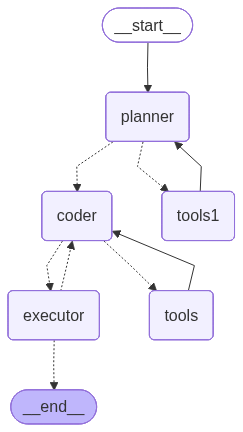

In [260]:
memory = MemorySaver()
graph = workflow.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [261]:
config = {"configurable": {"thread_id": "1"}}
task = "Write a Python function that takes a list of numbers and returns the sum, then call it with [1, 2, 3, 4, 5] and print the result"
result = await graph.ainvoke({"messages": [HumanMessage(content=task)], "task": task}, config)
